# 1. Cargar el dataset

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    balanced_accuracy_score, 
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import warnings
warnings.filterwarnings('ignore')


In [43]:
# Cargamos el archivo parquet

df_original= pd.read_parquet('cartera_q1_2026_final.parquet')

df_autos = df_original[df_original['ramo'] == 'Autos'].copy()
df_autos.info()
filas, columnas = df_autos.shape
print()
print(f"Quedaron exactamente {filas:,} registros (filas) y {columnas} campos (columnas).")

<class 'pandas.core.frame.DataFrame'>
Index: 14752 entries, 1 to 49997
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_poliza              14752 non-null  object        
 1   num_poliza             14752 non-null  object        
 2   nombre                 14752 non-null  category      
 3   apellido_paterno       14752 non-null  category      
 4   apellido_materno       14752 non-null  category      
 5   rfc                    14752 non-null  object        
 6   edad                   14752 non-null  int8          
 7   sexo                   14752 non-null  category      
 8   estado_civil           14752 non-null  category      
 9   ocupacion              13568 non-null  category      
 10  ramo                   14752 non-null  category      
 11  plan                   14752 non-null  category      
 12  fecha_emision          14752 non-null  datetime64[ns]
 13  fecha_

In [44]:
# --- CONTEO RÁPIDO DE VARIABLES CON NULOS ---
# 1. Cuántas columnas tienen al menos un valor nulo
cols_con_nulos = df_autos.isnull().any().sum()
print(f"Número de variables con al menos un dato nulo: {cols_con_nulos}")

# 2. Detalle de cuántos nulos tiene cada columna (solo las que tienen nulos)
null_counts = df_autos.isnull().sum()
detalle_nulos = null_counts[null_counts > 0]

print("\n--- Detalle de variables con nulos ---")
if not detalle_nulos.empty:
    print(detalle_nulos)
else:
    print("¡No hay variables con datos nulos! Tu dataset está limpio.")

Número de variables con al menos un dato nulo: 4

--- Detalle de variables con nulos ---
ocupacion          1184
motivo_baja       14006
codigo_postal       450
tipo_principal    10333
dtype: int64


In [45]:
# ==============================================================================
# MEMORIA DE IMPUTACIÓN Y LIMPIEZA DE DATOS (df_autos)
# ==============================================================================
# NOTAS DE CONTROL 
# ==============================================================================
# • df_autos['ocupacion']: Seguirá siendo tipo 'category'. Los nulos se vuelven 'Desconocido'.
# • df_autos['codigo_postal']: Seguirá siendo 'float64'. Se llena con el CP más común de su municipio/estado.
# • df_autos['status_poliza']: Mantiene intacto su tipo 'category' original. No sufre cambios.
# • df_autos['motivo_baja']: Seguirá siendo tipo 'category'. Los nulos se llenan con el texto de 'status_poliza'.
# • df_autos['tipo_principal']: Seguirá siendo tipo 'object'. Los nulos se llenan con el texto 'No identificado'.
#   Al mantener 'object' y 'category' separados, Pandas permite hacer análisis descriptivos 
#   y tablas cruzadas (crosstab) de forma nativa sin ningún conflicto.
# =====================================================================
# 1. Variable: 'ocupacion' (Tipo: category)
# Criterio: Imputar valores nulos con "Desconocido".
# ------------------------------------------------------------------------------
if 'Desconocido' not in df_autos['ocupacion'].cat.categories:
    df_autos['ocupacion'] = df_autos['ocupacion'].cat.add_categories(['Desconocido'])
df_autos['ocupacion'] = df_autos['ocupacion'].fillna('Desconocido')


# 2. Variable: 'motivo_baja' (Tipo: category)
# Criterio: Usar el valor de 'status_poliza'.
# Solución técnica: Conversión a 'object' para evitar TypeError por categorías no idénticas.
# ------------------------------------------------------------------------------
df_autos['motivo_baja'] = df_autos['motivo_baja'].astype('object')
df_autos['motivo_baja'] = df_autos['motivo_baja'].fillna(df_autos['status_poliza'])
df_autos['motivo_baja'] = df_autos['motivo_baja'].astype('category')


# 3. Variable: 'codigo_postal' (Tipo: float64)
# Criterio: Imputar con la moda calculada por 'estado' y 'municipio'.
# ------------------------------------------------------------------------------
moda_cp = df_autos.groupby(['estado', 'municipio'])['codigo_postal'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)
df_autos['codigo_postal'] = df_autos['codigo_postal'].fillna(moda_cp)


# 4. Variable: 'tipo_principal' (Tipo: object)
# Criterio: Imputar con "No identificado".
# ------------------------------------------------------------------------------
df_autos['tipo_principal'] = df_autos['tipo_principal'].fillna('No identificado')

# ==============================================================================
# CONFIRMACIÓN DE INTEGRIDAD
# ==============================================================================
print("Imputación finalizada. Verificación de tipos:")
print(df_autos[['ocupacion', 'motivo_baja', 'codigo_postal', 'tipo_principal']].dtypes)
print("\nConteo de nulos restantes:")
print(df_autos[['ocupacion', 'motivo_baja', 'codigo_postal', 'tipo_principal']].isna().sum())

Imputación finalizada. Verificación de tipos:
ocupacion         category
motivo_baja       category
codigo_postal      float64
tipo_principal      object
dtype: object

Conteo de nulos restantes:
ocupacion         0
motivo_baja       0
codigo_postal     0
tipo_principal    0
dtype: int64


In [46]:
#Base de datos sin nulos

df_autos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14752 entries, 1 to 49997
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_poliza              14752 non-null  object        
 1   num_poliza             14752 non-null  object        
 2   nombre                 14752 non-null  category      
 3   apellido_paterno       14752 non-null  category      
 4   apellido_materno       14752 non-null  category      
 5   rfc                    14752 non-null  object        
 6   edad                   14752 non-null  int8          
 7   sexo                   14752 non-null  category      
 8   estado_civil           14752 non-null  category      
 9   ocupacion              14752 non-null  category      
 10  ramo                   14752 non-null  category      
 11  plan                   14752 non-null  category      
 12  fecha_emision          14752 non-null  datetime64[ns]
 13  fecha_

In [47]:
# DEFINICION DE PALETA DE COLORES PARA TODO EL PROYECTO.

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex
import numpy as np

# 1. Define tu paleta base
colores_base = ["#2C3E50", "#1ABC9C", "#95A5A6", "#E67E22", "#34495E"]

def obtener_paleta_hex(n):
    """Devuelve una lista de n colores en formato HEX."""
    if n <= 1: return [colores_base[0]]
    cmap = LinearSegmentedColormap.from_list("custom_exec", colores_base, N=n)
    # Convertimos los colores generados a formato HEX para que sirvan en CSS (Tablas)
    return [to_hex(cmap(i)) for i in np.linspace(0, 1, n)]

In [48]:
# 2. Configuración global: Que muestre absolutamente todo
pd.set_option('display.max_rows', None)        # Mostrar todas las filas
pd.set_option('display.max_columns', None)     # Mostrar todas las columnas
pd.set_option('display.max_colwidth', None)    # No cortar texto en celdas

## Definición de variables features y targets

In [49]:
# --- 1. CONFIGURACIÓN Y DEFINICIONES ---
# (Tus listas originales integradas)
cols_features = [
    'edad', 'sexo', 'estado_civil', 'ocupacion', 'plan',
    'fecha_emision', 'fecha_inicio_vigencia', 'fecha_fin_vigencia',
    'num_renovaciones', 'status_poliza', 'motivo_baja', 'canal_venta',
    'marca_vehiculo', 'modelo_vehiculo', 'tipo_vehiculo', 'suma_asegurada',
    'deducible', 'prima_total', 'forma_pago', 'estado', 'codigo_postal',
    'region', 'monto_reclamado', 'tiene_abierto', 'prima_mensual',
    'nivel_riesgo', 'anio_emision', 'mes_emision', 'trimestre',
    'segmento_prima_fijo', 'cuartil_prima', 'anio_poliza',
    'antiguedad_vehiculo', 'g_edad'
]

cols_target = ['prima_neta', 'n_siniestros', 'monto_pagado']
cols_exclude = ['ramo', 'agente_id', 'rfc', 'nombre_agente', 'comision_pct', 
                'tipo_principal', 'loss_ratio', 'comision_est', 'cod_ramo', 
                'municipio', 'tipo_agente', 'ramo_desde_codigo']

In [50]:
# Convertir a formato fecha si no lo están
df_autos['fecha_inicio_vigencia'] = pd.to_datetime(df_autos['fecha_inicio_vigencia'])
# Si tienes el año del modelo, la antigüedad es el año actual - año del modelo
# O si tienes una fecha de fin de vigencia:
df_autos['antiguedad_vehiculo'] = df_autos['fecha_inicio_vigencia'].dt.year - df_autos['modelo_vehiculo']

In [51]:
# 1. Definimos los límites de los grupos (bins)
cortes = [17, 30, 45, 60, np.inf]

# 2. Definimos los nombres de las categorías correspondientes
etiquetas = ['18-30', '31-45', '46-60', '61+']

# 3. Aplicamos pd.cut para crear la nueva columna
df_autos['g_edad'] = pd.cut(df_autos['edad'], bins=cortes, labels=etiquetas, right=True)

# Modelos para estimar las variables target

## XGBoost

Primero analizaremos el modelo incluyendo la suma asegurada

In [52]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad', 'suma_asegurada']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']
cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)

print(f"All Colums: {all_columns}")

All Colums: 57


In [53]:
## Preparación del conjunto de datos

TARGET_COLUMNS = ['prima_neta','n_siniestros','monto_pagado']

TARGET = "prima_neta"
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

X_raw = df_autos[cols_features]
y     = df_autos[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 52 columnas
Ejemplos de nuevas columnas: ['edad', 'suma_asegurada', 'modelo_vehiculo', 'plan_20 anios', 'plan_Amplia'] ...

Train: 11,801 filas | Test: 2,951 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [54]:
# Entrenamiento de los modelos

xgb_conserv = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=20,
    subsample=1.0,
    random_state=SEED,
    tree_method='hist',
    device='cuda' 
)

# Entrenamiento del modelo
xgb_conserv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Predicciones
y_pred_conserv = xgb_conserv.predict(X_test)

# Evaluación
rmse_conserv = np.sqrt(mean_squared_error(y_test, y_pred_conserv))
r2_conserv   = r2_score(y_test, y_pred_conserv)

print(f"XGBoost conservador (lr=0.05, depth=3): RMSE={rmse_conserv:,.0f} MXN | R²={r2_conserv:.4f}")

xgb_flex = XGBRegressor(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=5,
    subsample=0.8,
    random_state=SEED,
    tree_method='hist', 
    device='cuda'
)

xgb_flex.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
y_pred_flex = xgb_flex.predict(X_test)

rmse_flex = np.sqrt(mean_squared_error(y_test, y_pred_flex))
r2_flex   = r2_score(y_test, y_pred_flex)
print(f"XGBoost flexible (lr=0.15, depth=5):    RMSE={rmse_flex:,.0f} MXN | R²={r2_flex:.4f}")

XGBoost conservador (lr=0.05, depth=3): RMSE=1,419 MXN | R²=0.9671
XGBoost flexible (lr=0.15, depth=5):    RMSE=1,466 MXN | R²=0.9649


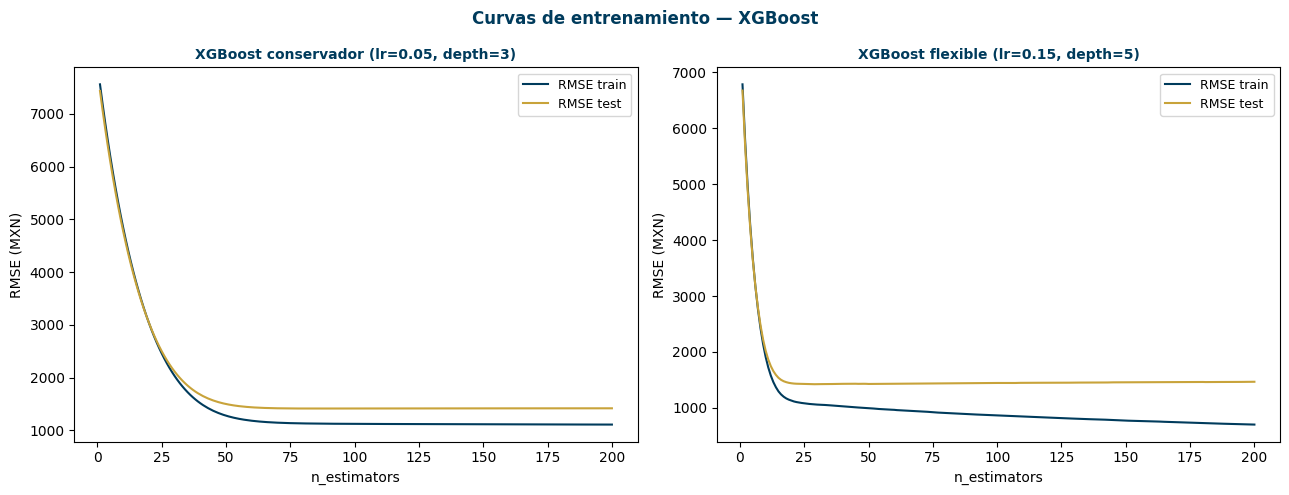

Observación: la configuración flexible muestra mayor gap train/test,
señal de sobreajuste incipiente a medida que aumentan los árboles.


In [55]:
# XGBoost grafica

# Extracción de los resultados (reemplaza a staged_predict)
res_conserv = xgb_conserv.evals_result()
rmse_tr_c = res_conserv['validation_0']['rmse'] # Error en train
rmse_te_c = res_conserv['validation_1']['rmse'] # Error en test

res_flex = xgb_flex.evals_result()
rmse_tr_f = res_flex['validation_0']['rmse']
rmse_te_f = res_flex['validation_1']['rmse']

# Definimos el rango del eje X (1 a 200 árboles)
n_range = range(1, len(rmse_tr_c) + 1)

# Creación de los gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tr, te, titulo in [
    (axes[0], rmse_tr_c, rmse_te_c, "XGBoost conservador (lr=0.05, depth=3)"),
    (axes[1], rmse_tr_f, rmse_te_f, "XGBoost flexible (lr=0.15, depth=5)"),
]:
    ax.plot(n_range, tr, color=NAVY, linewidth=1.5, label="RMSE train")
    ax.plot(n_range, te, color=GOLD, linewidth=1.5, label="RMSE test")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("RMSE (MXN)")
    ax.set_title(titulo, fontsize=10, fontweight="bold", color=NAVY)
    ax.legend(fontsize=9)

fig.suptitle("Curvas de entrenamiento — XGBoost",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

print("Observación: la configuración flexible muestra mayor gap train/test,")
print("señal de sobreajuste incipiente a medida que aumentan los árboles.")

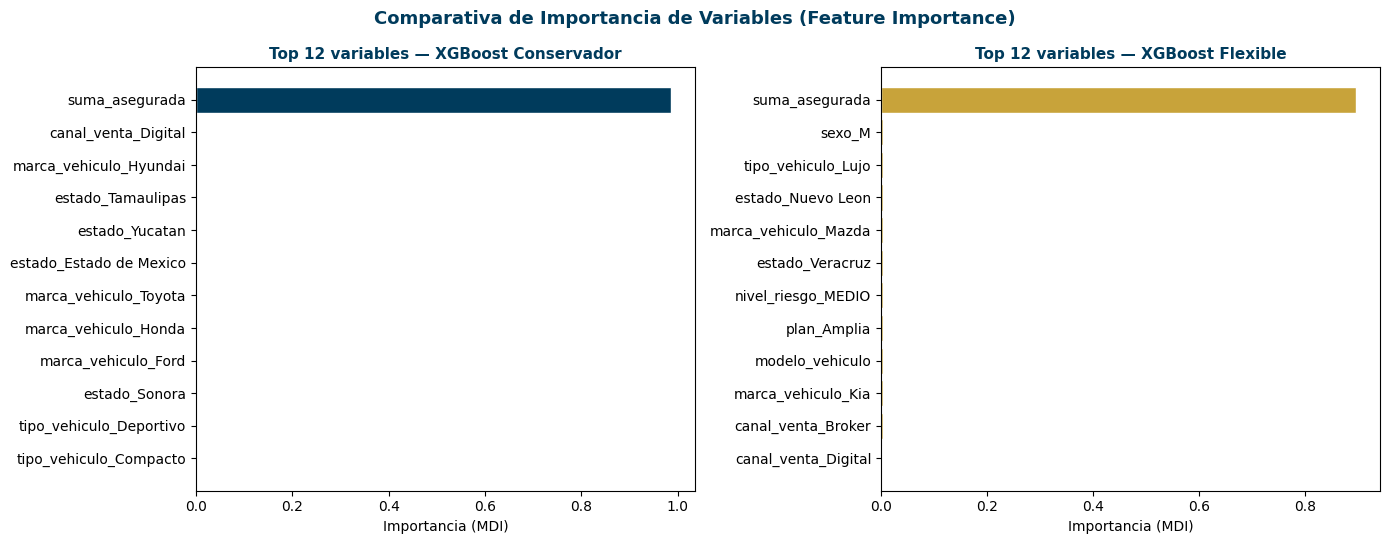

In [56]:
# 1. Extraer importancias del modelo conservador
import_conserv = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_conserv.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 2. Extraer importancias del modelo flexible
import_flex = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_flex.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 3. Crear la figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Gráfico 1: Modelo Conservador ---
axes[0].barh(import_conserv["Feature"], import_conserv["Importancia"],
             color=NAVY, edgecolor="white")
axes[0].set_xlabel("Importancia (MDI)")
axes[0].set_title("Top 12 variables — XGBoost Conservador",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[0].invert_yaxis() # Para que la más importante quede arriba

# --- Gráfico 2: Modelo Flexible ---
axes[1].barh(import_flex["Feature"], import_flex["Importancia"],
             color=GOLD, edgecolor="white") # Usamos GOLD para contrastar
axes[1].set_xlabel("Importancia (MDI)")
axes[1].set_title("Top 12 variables — XGBoost Flexible",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[1].invert_yaxis()

# Ajustes finales de diseño
fig.suptitle("Comparativa de Importancia de Variables (Feature Importance)", 
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

Como vemos la variable mas importante es la suma asegurada, como ya lo veniamos diciendo

Ahora, haremos el mismo ejercicio, pero quitando la suma asegurada

In [57]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']

cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)
print(f"All Colums: {all_columns}")

All Colums: 57


In [58]:
## Preparación del conjunto de datos

TARGET_COLUMNS = ['prima_neta','n_siniestros','monto_pagado']

TARGET = "prima_neta"
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

X_raw = df_autos[cols_features]
y     = df_autos[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 51 columnas
Ejemplos de nuevas columnas: ['edad', 'modelo_vehiculo', 'plan_20 anios', 'plan_Amplia', 'plan_Amplia Plus'] ...

Train: 11,801 filas | Test: 2,951 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [59]:
# Entrenamiento de los modelos

xgb_conserv = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=20,
    subsample=1.0,
    random_state=SEED,
    tree_method='hist',
    device='cuda' 
)

# Entrenamiento del modelo
xgb_conserv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Predicciones
y_pred_conserv = xgb_conserv.predict(X_test)

# Evaluación
rmse_conserv = np.sqrt(mean_squared_error(y_test, y_pred_conserv))
r2_conserv   = r2_score(y_test, y_pred_conserv)

print(f"XGBoost conservador (lr=0.05, depth=3): RMSE={rmse_conserv:,.0f} MXN | R²={r2_conserv:.4f}")

xgb_flex = XGBRegressor(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=5,
    subsample=0.8,
    random_state=SEED,
    tree_method='hist', 
    device='cuda'
)

xgb_flex.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
y_pred_flex = xgb_flex.predict(X_test)

rmse_flex = np.sqrt(mean_squared_error(y_test, y_pred_flex))
r2_flex   = r2_score(y_test, y_pred_flex)
print(f"XGBoost flexible (lr=0.15, depth=5):    RMSE={rmse_flex:,.0f} MXN | R²={r2_flex:.4f}")

XGBoost conservador (lr=0.05, depth=3): RMSE=7,852 MXN | R²=-0.0085
XGBoost flexible (lr=0.15, depth=5):    RMSE=8,101 MXN | R²=-0.0736


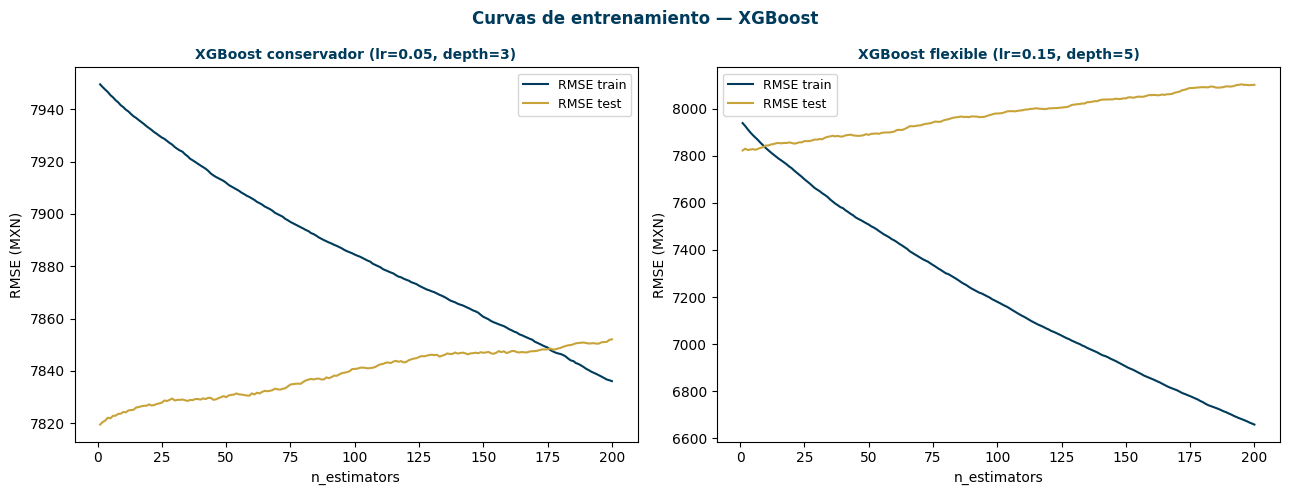

In [60]:
# XGBoost grafica

# Extracción de los resultados (reemplaza a staged_predict)
res_conserv = xgb_conserv.evals_result()
rmse_tr_c = res_conserv['validation_0']['rmse'] # Error en train
rmse_te_c = res_conserv['validation_1']['rmse'] # Error en test

res_flex = xgb_flex.evals_result()
rmse_tr_f = res_flex['validation_0']['rmse']
rmse_te_f = res_flex['validation_1']['rmse']

# Definimos el rango del eje X (1 a 200 árboles)
n_range = range(1, len(rmse_tr_c) + 1)

# Creación de los gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tr, te, titulo in [
    (axes[0], rmse_tr_c, rmse_te_c, "XGBoost conservador (lr=0.05, depth=3)"),
    (axes[1], rmse_tr_f, rmse_te_f, "XGBoost flexible (lr=0.15, depth=5)"),
]:
    ax.plot(n_range, tr, color=NAVY, linewidth=1.5, label="RMSE train")
    ax.plot(n_range, te, color=GOLD, linewidth=1.5, label="RMSE test")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("RMSE (MXN)")
    ax.set_title(titulo, fontsize=10, fontweight="bold", color=NAVY)
    ax.legend(fontsize=9)

fig.suptitle("Curvas de entrenamiento — XGBoost",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

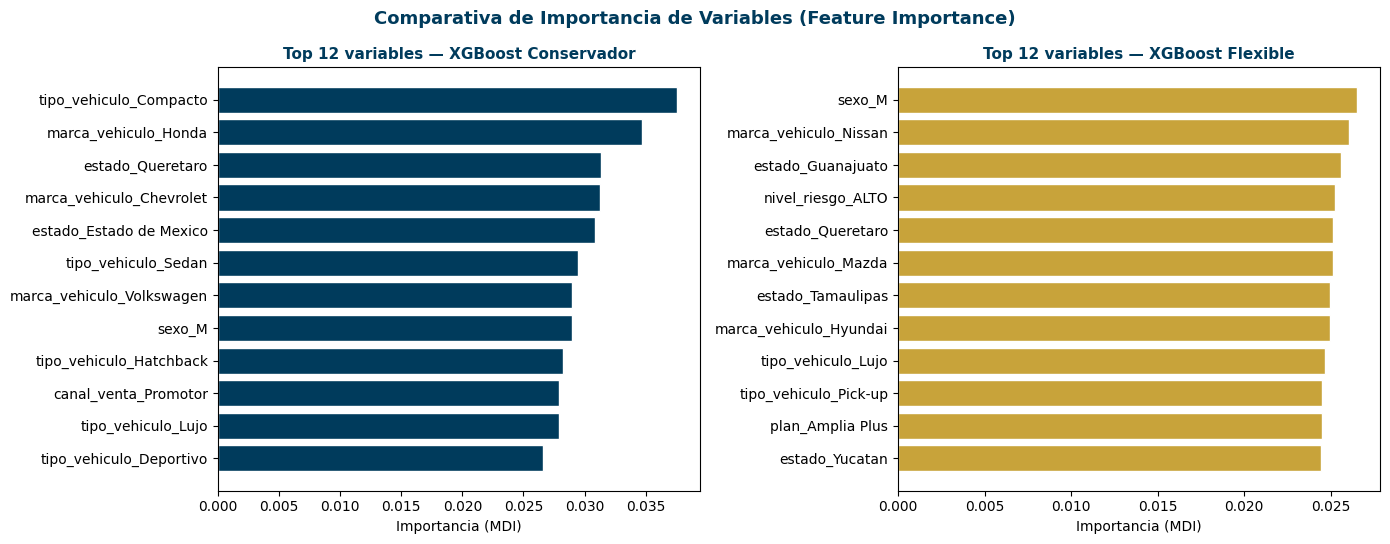

In [61]:
# 1. Extraer importancias del modelo conservador
import_conserv = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_conserv.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 2. Extraer importancias del modelo flexible
import_flex = pd.DataFrame({
    "Feature": X_train.columns,
    "Importancia": xgb_flex.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

# 3. Crear la figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Gráfico 1: Modelo Conservador ---
axes[0].barh(import_conserv["Feature"], import_conserv["Importancia"],
             color=NAVY, edgecolor="white")
axes[0].set_xlabel("Importancia (MDI)")
axes[0].set_title("Top 12 variables — XGBoost Conservador",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[0].invert_yaxis() # Para que la más importante quede arriba

# --- Gráfico 2: Modelo Flexible ---
axes[1].barh(import_flex["Feature"], import_flex["Importancia"],
             color=GOLD, edgecolor="white") # Usamos GOLD para contrastar
axes[1].set_xlabel("Importancia (MDI)")
axes[1].set_title("Top 12 variables — XGBoost Flexible",
                  fontsize=11, fontweight="bold", color=NAVY)
axes[1].invert_yaxis()

# Ajustes finales de diseño
fig.suptitle("Comparativa de Importancia de Variables (Feature Importance)", 
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

Como podemos ver, al quitar la suma asegurada, el modelo no sabe como predecir y el RMSE se cae

Continuaremos con el modelo que usa la suma asegurada

In [62]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad', 'suma_asegurada']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']

cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)
print(f"All Colums: {all_columns}")

All Colums: 57


In [63]:
## Preparación del conjunto de datos

TARGET_COLUMNS = ['prima_neta','n_siniestros','monto_pagado']


TARGET = "prima_neta"
SEED  = 20260618
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

X_raw = df_autos[cols_features]
y     = df_autos[TARGET]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

# Split 80/20 en train/test; random_state fija una partición reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Verificar que no hay targets en X
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} está en X"
print("✓ Ningún target en X")
assert "id_poliza_sin" not in X.columns
print("✓ id_poliza_sin excluido")

Features tras OHE: 52 columnas
Ejemplos de nuevas columnas: ['edad', 'suma_asegurada', 'modelo_vehiculo', 'plan_20 anios', 'plan_Amplia'] ...

Train: 11,801 filas | Test: 2,951 filas
✓ Ningún target en X
✓ id_poliza_sin excluido


In [64]:
# Entrenamiento de los modelos

xgb_conserv = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=20,
    subsample=1.0,
    random_state=SEED,
    tree_method='hist',
    device='cuda' 
)

# Entrenamiento del modelo
xgb_conserv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Predicciones
y_pred_conserv = xgb_conserv.predict(X_test)

# Evaluación
rmse_conserv = np.sqrt(mean_squared_error(y_test, y_pred_conserv))
r2_conserv   = r2_score(y_test, y_pred_conserv)

print(f"XGBoost conservador (lr=0.05, depth=3): RMSE={rmse_conserv:,.0f} MXN | R²={r2_conserv:.4f}")

xgb_flex = XGBRegressor(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=5,
    subsample=0.8,
    random_state=SEED,
    tree_method='hist', 
    device='cuda'
)

xgb_flex.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
y_pred_flex = xgb_flex.predict(X_test)

rmse_flex = np.sqrt(mean_squared_error(y_test, y_pred_flex))
r2_flex   = r2_score(y_test, y_pred_flex)
print(f"XGBoost flexible (lr=0.15, depth=5):    RMSE={rmse_flex:,.0f} MXN | R²={r2_flex:.4f}")

XGBoost conservador (lr=0.05, depth=3): RMSE=1,419 MXN | R²=0.9671
XGBoost flexible (lr=0.15, depth=5):    RMSE=1,466 MXN | R²=0.9649


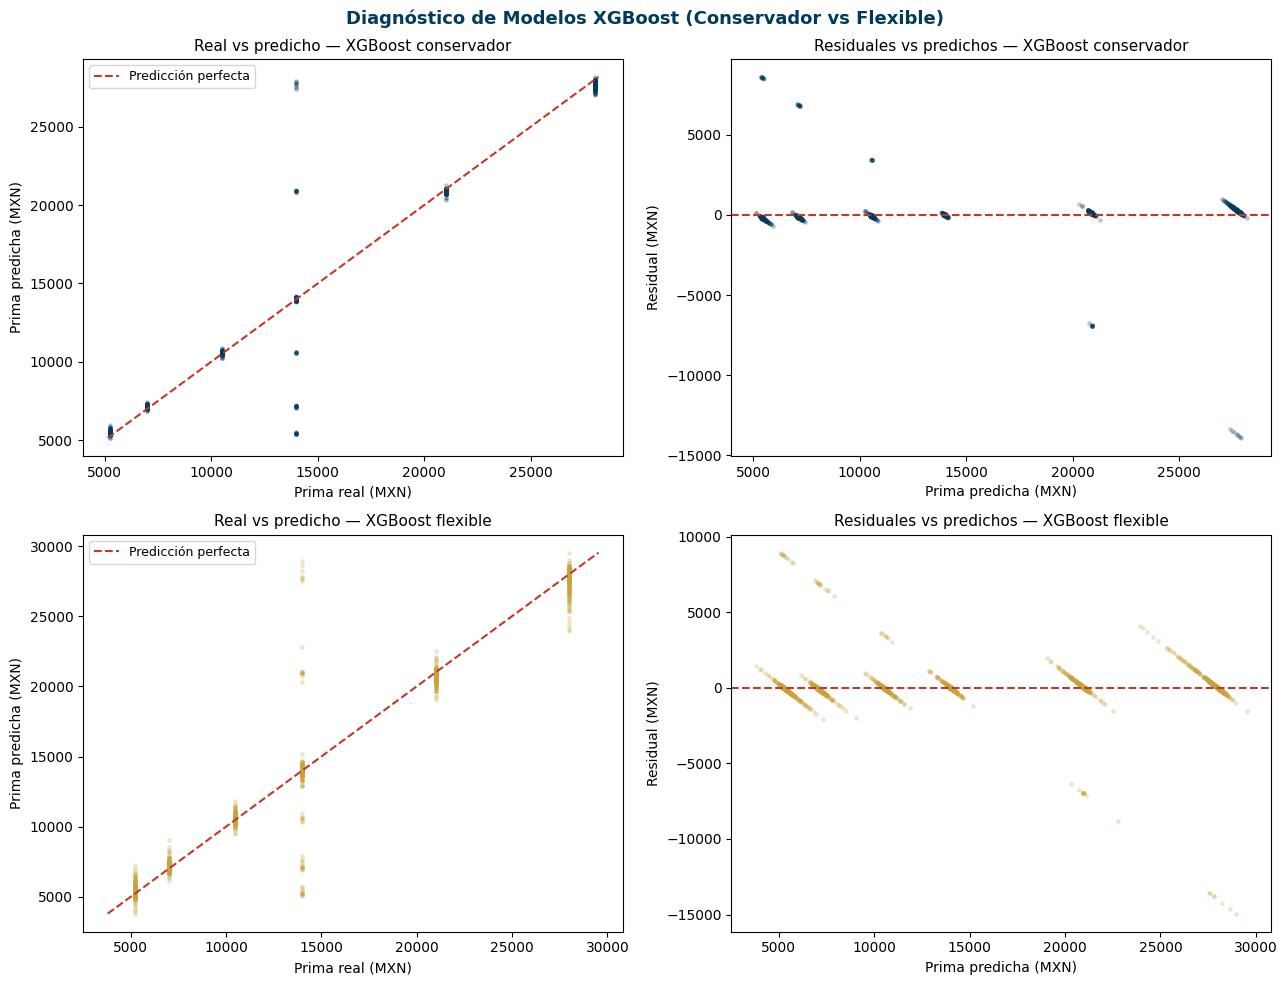

In [65]:
# Graficas

rng = np.random.default_rng(SEED)
idx = rng.choice(len(y_test), size=min(2_000, len(y_test)), replace=False)

# Extraemos los valores reales y las predicciones de ambos modelos
y_r = y_test.iloc[idx].values
y_p_conserv = y_pred_conserv[idx]
y_p_flex = y_pred_flex[idx] # Agregamos las predicciones del modelo flexible

# Creamos una figura más alta con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- FILA 1: Modelo Conservador (Color NAVY) ---

# 1. Real vs Predicho (Conservador)
axes[0, 0].scatter(y_r, y_p_conserv, alpha=0.2, s=6, color=NAVY)
lims_c = [min(y_r.min(), y_p_conserv.min()), max(y_r.max(), y_p_conserv.max())]
axes[0, 0].plot(lims_c, lims_c, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[0, 0].set_xlabel("Prima real (MXN)")
axes[0, 0].set_ylabel("Prima predicha (MXN)")
axes[0, 0].set_title("Real vs predicho — XGBoost conservador", fontsize=11)
axes[0, 0].legend(fontsize=9)

# 2. Residuales vs Predichos (Conservador)
res_c = y_r - y_p_conserv
axes[0, 1].scatter(y_p_conserv, res_c, alpha=0.2, s=6, color=NAVY)
axes[0, 1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[0, 1].set_xlabel("Prima predicha (MXN)")
axes[0, 1].set_ylabel("Residual (MXN)")
axes[0, 1].set_title("Residuales vs predichos — XGBoost conservador", fontsize=11)


# --- FILA 2: Modelo Flexible (Color GOLD) ---

# 3. Real vs Predicho (Flexible)
axes[1, 0].scatter(y_r, y_p_flex, alpha=0.2, s=6, color=GOLD)
lims_f = [min(y_r.min(), y_p_flex.min()), max(y_r.max(), y_p_flex.max())]
axes[1, 0].plot(lims_f, lims_f, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[1, 0].set_xlabel("Prima real (MXN)")
axes[1, 0].set_ylabel("Prima predicha (MXN)")
axes[1, 0].set_title("Real vs predicho — XGBoost flexible", fontsize=11)
axes[1, 0].legend(fontsize=9)

# 4. Residuales vs Predichos (Flexible)
res_f = y_r - y_p_flex
axes[1, 1].scatter(y_p_flex, res_f, alpha=0.2, s=6, color=GOLD)
axes[1, 1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1, 1].set_xlabel("Prima predicha (MXN)")
axes[1, 1].set_ylabel("Residual (MXN)")
axes[1, 1].set_title("Residuales vs predichos — XGBoost flexible", fontsize=11)

# Ajuste global del título y los márgenes
fig.suptitle("Diagnóstico de Modelos XGBoost (Conservador vs Flexible)",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

## Red neuronal

In [93]:
# Clasificación de variables

cols_target = ['prima_neta','n_siniestros','monto_pagado']

cols_feature_num = ['edad', 'suma_asegurada']
cols_feature_cat = ['plan','sexo','canal_venta','marca_vehiculo','tipo_vehiculo','modelo_vehiculo','estado','nivel_riesgo']

cols_features = cols_feature_num + cols_feature_cat

cols_pii = df_autos.columns.drop(cols_features).tolist()

X_raw = df_autos[cols_features]

all_columns = len(cols_features) + len(cols_target) + len(cols_pii)
print(f"All Colums: {all_columns}")

All Colums: 58


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,} obs.  |  Test: {X_test.shape[0]:,} obs.")

Train: 11,801 obs.  |  Test: 2,951 obs.


In [68]:
# Validamos los datos del train

X_train_core, X_val, y_train_core, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED
)
print(f"Split interno de train:")
print(f"  Train core (selección): {X_train_core.shape[0]:,} obs.")
print(f"  Validation (selección): {X_val.shape[0]:,} obs.")
print(f"  Test (evaluación final, intocado): {X_test.shape[0]:,} obs.")
print()
print("Las 3 configuraciones MLP se evaluarán únicamente en validation.")
print("El test set se evaluará UNA sola vez con el modelo final seleccionado.")

Split interno de train:
  Train core (selección): 9,440 obs.
  Validation (selección): 2,361 obs.
  Test (evaluación final, intocado): 2,951 obs.

Las 3 configuraciones MLP se evaluarán únicamente en validation.
El test set se evaluará UNA sola vez con el modelo final seleccionado.


In [69]:
# Preprocesador para MLP

def make_mlp_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para MLP y OLS."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), cols_feature_num),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
             cols_feature_cat),
        ],
        remainder="drop",
    )

# Verificar dimensión del espacio transformado — instancia de verificación, no reutilizada en pipelines
_pre_check = make_mlp_preprocessor().fit(X_train)
n_features_out = _pre_check.transform(X_train).shape[1]
print(f"Espacio OHE: {n_features_out} features de entrada al MLP")
print(f"  Numéricas (escaladas):   {len(cols_feature_num)}")
print(f"  Categóricas (OHE − 1):  {n_features_out - len(cols_feature_num)}")
n_features_out = _pre_check.transform(X_train).shape[1]
print(f"Espacio OHE: {n_features_out} features de entrada al MLP")
print(f"  Numéricas (escaladas):   {len(cols_feature_num)}")
print(f"  Categóricas (OHE − 1):  {n_features_out - len(cols_feature_num)}")

Espacio OHE: 52 features de entrada al MLP
  Numéricas (escaladas):   2
  Categóricas (OHE − 1):  50
Espacio OHE: 52 features de entrada al MLP
  Numéricas (escaladas):   2
  Categóricas (OHE − 1):  50


In [70]:
# Entrenamiento de MLP con validación interna

configuraciones_val = [
    {"hidden_layer_sizes": (64, 32),  "alpha": 0.001, "label": "(64,32) α=0.001  [base]"},
    {"hidden_layer_sizes": (128, 64), "alpha": 0.001, "label": "(128,64) α=0.001  [más parámetros]"},
    {"hidden_layer_sizes": (64, 32),  "alpha": 0.010, "label": "(64,32) α=0.010  [más regularización]"},
]

print("Evaluación de configuraciones MLP — RMSE en validation:")
print("(Entrenamiento en train_core | Test intocado)")
print()

resultados_val = []
for cfg in configuraciones_val:
    _inner = Pipeline([
        ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
        ("mlp", MLPRegressor(
            hidden_layer_sizes=cfg["hidden_layer_sizes"],
            activation="relu", solver="adam",
            alpha=cfg["alpha"], learning_rate_init=0.001,
            max_iter=500, early_stopping=True,
            validation_fraction=0.10, n_iter_no_change=20,
            batch_size="auto", random_state=SEED, verbose=False,
        )),
    ])
    _model = TransformedTargetRegressor(regressor=_inner, transformer=StandardScaler())
    _model.fit(X_train_core, y_train_core)
    _y_val_pred = _model.predict(X_val)
    _rmse_val   = np.sqrt(mean_squared_error(y_val, _y_val_pred))
    _r2_val     = r2_score(y_val, _y_val_pred)
    _n_iter     = _model.regressor_.named_steps["mlp"].n_iter_
    resultados_val.append({
        "label": cfg["label"],
        "hidden_layer_sizes": cfg["hidden_layer_sizes"],
        "alpha": cfg["alpha"],
        "rmse_val": _rmse_val,
        "r2_val": _r2_val,
        "n_iter": _n_iter,
    })
    print(f"  {cfg['label']:<40} RMSE_val={_rmse_val:,.1f}  R²_val={_r2_val:.4f}  épocas={_n_iter}")

# Selección: configuración con menor RMSE de validación
best_val = min(resultados_val, key=lambda d: d["rmse_val"])
print(f"\n→ Configuración seleccionada: {best_val['label']}")
print(f"  RMSE validation = {best_val['rmse_val']:,.1f} MXN  |  R² validation = {best_val['r2_val']:.4f}")

Evaluación de configuraciones MLP — RMSE en validation:
(Entrenamiento en train_core | Test intocado)

  (64,32) α=0.001  [base]                  RMSE_val=1,346.2  R²_val=0.9717  épocas=44
  (128,64) α=0.001  [más parámetros]       RMSE_val=1,313.8  R²_val=0.9731  épocas=32
  (64,32) α=0.010  [más regularización]    RMSE_val=1,346.9  R²_val=0.9717  épocas=44

→ Configuración seleccionada: (128,64) α=0.001  [más parámetros]
  RMSE validation = 1,313.8 MXN  |  R² validation = 0.9731


In [71]:
# Entrenamiento final: configuración seleccionada, reajuste sobre X_train completo (24,000 obs.)
mlp_inner = Pipeline([
    ("preprocessor", make_mlp_preprocessor()),  # instancia fresca — sin estado compartido
    ("mlp", MLPRegressor(
        hidden_layer_sizes=best_val["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=best_val["alpha"],
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        batch_size="auto",
        random_state=SEED,
        verbose=False,
    )),
])

# TransformedTargetRegressor escala prima_neta antes de entrenar
mlp_model = TransformedTargetRegressor(
    regressor=mlp_inner,
    transformer=StandardScaler(),
)

print(f"Entrenando MLP con configuración seleccionada: {best_val['label']}")
print(f"Datos de entrenamiento: X_train completo ({X_train.shape[0]:,} obs.)")
mlp_model.fit(X_train, y_train)

# Extraer el MLPRegressor para acceder a loss_curve_ y validation_scores_
mlp_raw = mlp_model.regressor_.named_steps["mlp"]

print(f"\nConvergencia:")
print(f"  Iteraciones realizadas: {mlp_raw.n_iter_}")
print(f"  Iteraciones máximas:    {mlp_raw.max_iter}")
print(f"  early_stopping activo:  {mlp_raw.early_stopping}")
if mlp_raw.n_iter_ < mlp_raw.max_iter:
    print(f"  → Convergió antes del máximo")
else:
    print(f"  → Alcanzó max_iter sin converger completamente")
print(f"  Objetivo final (train interno, escala estandarizada): {mlp_raw.loss_:.6f}")

# Nota sobre early stopping en sklearn MLPRegressor:
# Con early_stopping=True y una tarea de regresión, sklearn monitorea el R² en
# validation_fraction. Se detiene si el R² no mejora en n_iter_no_change iteraciones.
# (No monitorea la "pérdida de validación": validation_scores_ contiene R², no MSE.)
if hasattr(mlp_raw, "validation_scores_") and mlp_raw.validation_scores_ is not None:
    print(f"  R² de validación interna (último): {mlp_raw.validation_scores_[-1]:.4f}")
    print(f"  R² de validación interna (máx):   {max(mlp_raw.validation_scores_):.4f}")

Entrenando MLP con configuración seleccionada: (128,64) α=0.001  [más parámetros]
Datos de entrenamiento: X_train completo (11,801 obs.)

Convergencia:
  Iteraciones realizadas: 30
  Iteraciones máximas:    500
  early_stopping activo:  True
  → Convergió antes del máximo
  Objetivo final (train interno, escala estandarizada): 0.007410
  R² de validación interna (último): 0.9686
  R² de validación interna (máx):   0.9688


Early stopping monitorea R² de validación (no la pérdida de validación).
  R² máximo: 0.9688 (época 12)
  R² final:  0.9686


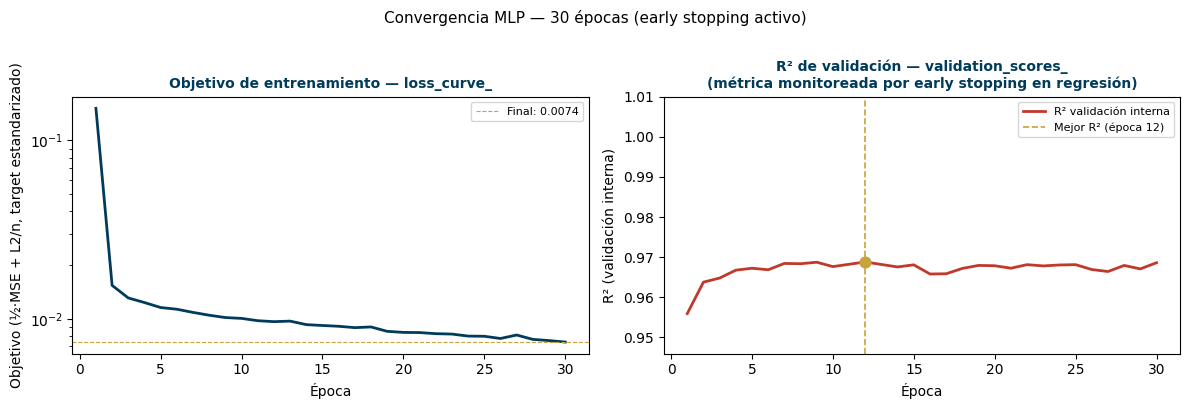


Curva loss_curve_: objetivo ½·MSE + L2/n sobre target estandarizado (NO es RMSE en MXN).
  Épocas: 30  |  Inicial: 0.1513  |  Final: 0.007410
  Reducción: 95.1%


In [72]:
loss_curve   = mlp_raw.loss_curve_
val_scores   = mlp_raw.validation_scores_ if hasattr(mlp_raw, "validation_scores_") else None
n_epochs     = len(loss_curve)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: objetivo de entrenamiento (loss_curve_)
ax1 = axes[0]
ax1.plot(range(1, n_epochs + 1), loss_curve, color=NAVY, linewidth=2.0)
ax1.set_xlabel("Época")
ax1.set_ylabel("Objetivo (½·MSE + L2/n, target estandarizado)")
ax1.set_title("Objetivo de entrenamiento — loss_curve_",
              fontsize=10, color=NAVY, fontweight="bold")
ax1.set_yscale("log")
ax1.axhline(loss_curve[-1], color=GOLD, linewidth=0.8, linestyle="--",
            label=f"Final: {loss_curve[-1]:.4f}")
ax1.legend(fontsize=8)

# Panel 2: R² de validación interna (validation_scores_)
ax2 = axes[1]
if val_scores is not None:
    best_epoch = int(np.argmax(val_scores)) + 1
    ax2.plot(range(1, len(val_scores) + 1), val_scores,
             color=RED, linewidth=2.0, label="R² validación interna")
    ax2.axvline(best_epoch, color=GOLD, linewidth=1.2, linestyle="--",
                label=f"Mejor R² (época {best_epoch})")
    ax2.scatter([best_epoch], [max(val_scores)],
                color=GOLD, s=60, zorder=5)
    ax2.set_xlabel("Época")
    ax2.set_ylabel("R² (validación interna)")
    ax2.set_title("R² de validación — validation_scores_\n"
                  "(métrica monitoreada por early stopping en regresión)",
                  fontsize=10, color=NAVY, fontweight="bold")
    ax2.legend(fontsize=8)
    ax2.set_ylim([max(0, min(val_scores) - 0.01), 1.01])
    print(f"Early stopping monitorea R² de validación (no la pérdida de validación).")
    print(f"  R² máximo: {max(val_scores):.4f} (época {best_epoch})")
    print(f"  R² final:  {val_scores[-1]:.4f}")
else:
    ax2.text(0.5, 0.5, "validation_scores_ no disponible",
             ha="center", va="center", transform=ax2.transAxes)

plt.suptitle(f"Convergencia MLP — {n_epochs} épocas (early stopping activo)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCurva loss_curve_: objetivo ½·MSE + L2/n sobre target estandarizado (NO es RMSE en MXN).")
print(f"  Épocas: {n_epochs}  |  Inicial: {loss_curve[0]:.4f}  |  Final: {loss_curve[-1]:.6f}")
print(f"  Reducción: {(1 - loss_curve[-1]/loss_curve[0])*100:.1f}%")

In [73]:
# Métricas finales en train y test

y_mlp_train = mlp_model.predict(X_train)
y_mlp_test  = mlp_model.predict(X_test)

rmse_mlp_train = np.sqrt(mean_squared_error(y_train, y_mlp_train))
rmse_mlp_test  = np.sqrt(mean_squared_error(y_test,  y_mlp_test))
mae_mlp_test   = mean_absolute_error(y_test, y_mlp_test)
r2_mlp_train   = r2_score(y_train, y_mlp_train)
r2_mlp_test    = r2_score(y_test,  y_mlp_test)

print("=" * 60)
print("MÉTRICAS FINALES — Test set")
print("(Evaluado una sola vez — no fue usado en selección)")
print("=" * 60)
print()
header = f"{'Modelo':<35} {'RMSE test':>10} {'MAE test':>10} {'R² test':>8} {'R² train':>9}"
print(header)
print("-" * len(header))

mlp_nombre = f"MLP {best_val['label']}"
print(f"{mlp_nombre:<35} {rmse_mlp_test:>10,.1f} {mae_mlp_test:>10,.1f} "
      f"{r2_mlp_test:>8.4f} {r2_mlp_train:>9.4f}")
print()
print(f"Configuración MLP seleccionada: {best_val['label']}")
print(f"  RMSE_validation = {best_val['rmse_val']:,.1f} MXN  |  R²_validation = {best_val['r2_val']:.4f}")

MÉTRICAS FINALES — Test set
(Evaluado una sola vez — no fue usado en selección)

Modelo                               RMSE test   MAE test  R² test  R² train
----------------------------------------------------------------------------
MLP (128,64) α=0.001  [más parámetros]    1,496.2      621.8   0.9634    0.9806

Configuración MLP seleccionada: (128,64) α=0.001  [más parámetros]
  RMSE_validation = 1,313.8 MXN  |  R²_validation = 0.9731


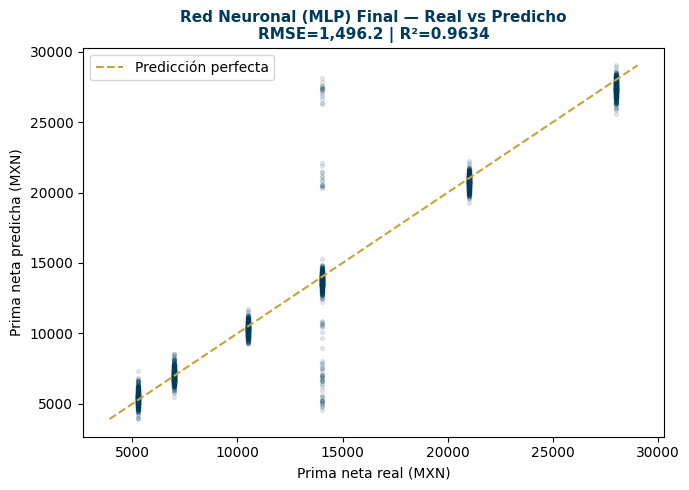

In [74]:
import matplotlib.pyplot as plt

# ── GRÁFICA DEL MODELO FINAL (MLP) ──────────────────────────────────
# Usamos el modelo que ya tienes entrenado en tu entorno
y_mlp_test = mlp_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test, y_mlp_test, alpha=0.1, s=8, color=NAVY)
lim = [min(y_test.min(), y_mlp_test.min()), max(y_test.max(), y_mlp_test.max())]
ax.plot(lim, lim, "--", color=GOLD, linewidth=1.5, label="Predicción perfecta")

ax.set_xlabel("Prima neta real (MXN)")
ax.set_ylabel("Prima neta predicha (MXN)")
ax.set_title(f"Red Neuronal (MLP) Final — Real vs Predicho\nRMSE={rmse_mlp_test:,.1f} | R²={r2_mlp_test:.4f}",
             fontsize=11, color=NAVY, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

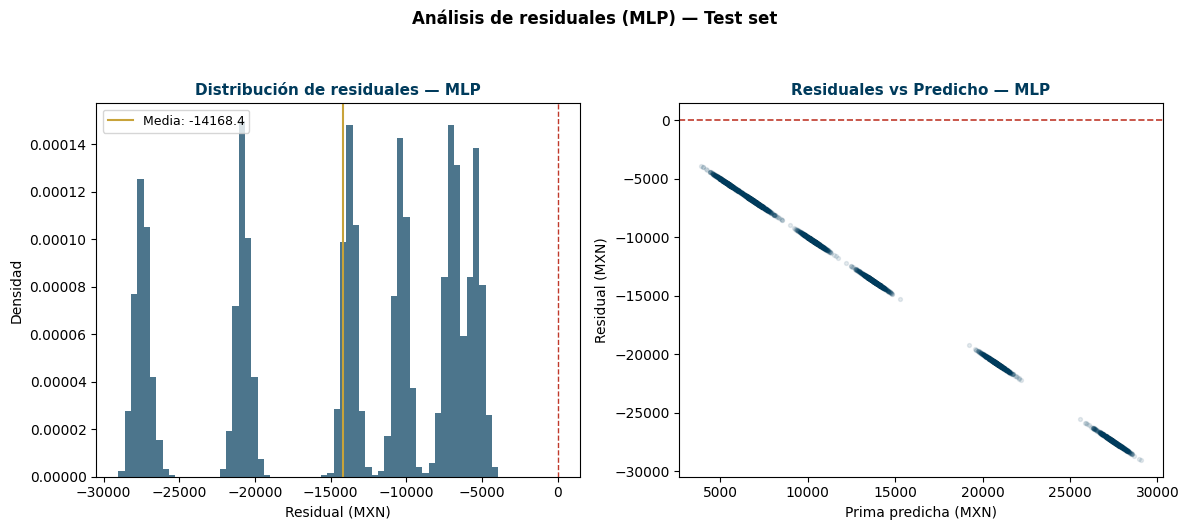

DIAGNÓSTICO CUANTITATIVO DE RESIDUALES (MLP):
Media de errores: -14168.45 MXN | Desviación estándar: 7,761.7 MXN
Correlación (predicción, |error|) = 1.000
Dispersión (Std) por decil de predicción: 199–2,800 MXN
------------------------------------------------------------
Nota: Un valor cercano a 0 en la correlación sugiere estabilidad en la varianza.


In [94]:
# ── ANÁLISIS DE RESIDUALES  ───
residuales_mlp = y_test.values - y_mlp_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Distribución de residuales
axes[0].hist(residuales_mlp, bins=60, color=NAVY, alpha=0.7, density=True)
axes[0].axvline(0, color=RED, linewidth=1.0, linestyle="--")
axes[0].axvline(residuales_mlp.mean(), color=GOLD, linewidth=1.5,
                linestyle="-", label=f"Media: {residuales_mlp.mean():.1f}")
axes[0].set_xlabel("Residual (MXN)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución de residuales — MLP", fontsize=11, color=NAVY, fontweight="bold")
axes[0].legend(fontsize=9)

# 2. Residuales vs predicho (Heterocedasticidad)
axes[1].scatter(y_mlp_test, residuales_mlp, alpha=0.1, s=8, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs Predicho — MLP", fontsize=11, color=NAVY, fontweight="bold")

plt.suptitle("Análisis de residuales (MLP) — Test set", fontsize=12, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# ── DIAGNÓSTICO CUANTITATIVO (SOLO MLP) ────────────────────────────────
corr_pred_abs_resid = float(np.corrcoef(y_mlp_test, np.abs(residuales_mlp))[0, 1])
_decile_idx = pd.qcut(y_mlp_test, 10, labels=False, duplicates="drop")
_decile_std = pd.Series(residuales_mlp).groupby(_decile_idx).std()
resid_std_decile_min = float(_decile_std.min())
resid_std_decile_max = float(_decile_std.max())

print("DIAGNÓSTICO CUANTITATIVO DE RESIDUALES (MLP):")
print(f"Media de errores: {residuales_mlp.mean():+.2f} MXN | Desviación estándar: {residuales_mlp.std():,.1f} MXN")
print(f"Correlación (predicción, |error|) = {corr_pred_abs_resid:.3f}")
print(f"Dispersión (Std) por decil de predicción: {resid_std_decile_min:,.0f}–{resid_std_decile_max:,.0f} MXN")
print("-" * 60)
print("Nota: Un valor cercano a 0 en la correlación sugiere estabilidad en la varianza.")

In [76]:
# Tabla resumen de resultados de validation
print("Tabla de selección — RMSE en validation (NO en test):")
print()
print(f"{'Configuración':<40} {'RMSE_val':>10} {'R²_val':>8} {'Épocas':>7}")
print("-" * 68)
for res in resultados_val:
    marca = " ← seleccionada" if res["label"] == best_val["label"] else ""
    print(f"  {res['label']:<38} {res['rmse_val']:>10,.1f} {res['r2_val']:>8.4f} {res['n_iter']:>7}{marca}")
print()
print(f"Modelo final (reentrenado sobre X_train completo, 24,000 obs.):")
print(f"  RMSE_test  = {rmse_mlp_test:,.1f} MXN")
print(f"  R²_test    = {r2_mlp_test:.4f}")
print()
print("Interpretación:")
print("• Las métricas de validation permiten seleccionar sin contaminar el test.")
print("• El reentrenamiento sobre el train completo puede cambiar las métricas")
print("  respecto a la evaluación en validation (más datos → puede mejorar o variar).")
print("• El RMSE_test es la estimación definitiva del desempeño sobre datos no vistos.")

Tabla de selección — RMSE en validation (NO en test):

Configuración                              RMSE_val   R²_val  Épocas
--------------------------------------------------------------------
  (64,32) α=0.001  [base]                   1,346.2   0.9717      44
  (128,64) α=0.001  [más parámetros]        1,313.8   0.9731      32 ← seleccionada
  (64,32) α=0.010  [más regularización]     1,346.9   0.9717      44

Modelo final (reentrenado sobre X_train completo, 24,000 obs.):
  RMSE_test  = 1,496.2 MXN
  R²_test    = 0.9634

Interpretación:
• Las métricas de validation permiten seleccionar sin contaminar el test.
• El reentrenamiento sobre el train completo puede cambiar las métricas
  respecto a la evaluación en validation (más datos → puede mejorar o variar).
• El RMSE_test es la estimación definitiva del desempeño sobre datos no vistos.


## Support Vector Machine

In [77]:
#Definición del Target y revisión

target_binaria = "ocurrencia_siniestro"
df_autos['ocurrencia_siniestro'] = (df_autos['n_siniestros'] > 0).astype(int)

# Distribución de la clase
vc = df_autos[target_binaria].value_counts(normalize=True) * 100
print("Distribución de siniestros:")
print(f"  0 (sin siniestro): {vc.get(0, 0):.1f}%")
print(f"  1 (con siniestro): {vc.get(1, 0):.1f}%")

# Verificar la definición: n_siniestros = int(n_siniestros > 0)
computed = (df_autos["n_siniestros"] > 0).astype(int)
assert (computed == df_autos[target_binaria]).all(), "El target no coincide con la definición esperada"
print("\n✓ n_siniestros == int(n_siniestros > 0) verificado")

Distribución de siniestros:
  0 (sin siniestro): 70.0%
  1 (con siniestro): 30.0%

✓ n_siniestros == int(n_siniestros > 0) verificado


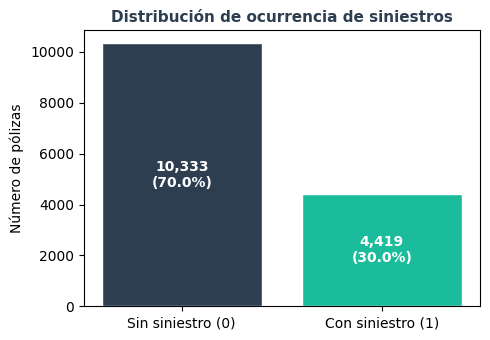

In [78]:
# Gráfica de la distribución de pólizas con y sin siniestros, en la base de Autos

colores_base = ["#2C3E50", "#1ABC9C", "#95A5A6", "#E67E22", "#34495E"]
COLOR_SIN = colores_base[0] # #2C3E50
COLOR_CON = colores_base[1] # #1ABC9C

# Preparación de datos
N = len(df_autos)
conteos = df_autos[target_binaria].value_counts().sort_index()
colores = [COLOR_SIN, COLOR_CON]

# Gráfica
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.bar(["Sin siniestro (0)", "Con siniestro (1)"],
       conteos.values, color=colores, edgecolor="white")

# Etiquetas
#offset = N * 0.02 
for i, v in enumerate(conteos.values):
    ax.text(i, v /2, f"{v:,}\n({(v/N)*100:.1f}%)", 
            ha="center", va="center", fontsize=10, fontweight='bold', color='white')
# Estilos
ax.set_ylabel("Número de pólizas")
ax.set_title("Distribución de ocurrencia de siniestros", fontsize=11, color=COLOR_SIN, fontweight='bold')

plt.tight_layout()
plt.show()

In [80]:
#Estas variables las definimos en el equipo comolas relevantes a utilizar en el modelo.

# Variables predictoras
FEATURE_COLUMNS = ['edad', 'plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

# Definir columnas numéricas y categóricas dentro de FEATURE_COLUMNS
NUMERIC_FEATURES = ["edad"]
CAT_FEATURES = ['plan', 'sexo', 'canal_venta', 'marca_vehiculo',
                   'tipo_vehiculo', 'modelo_vehiculo', 'estado']

TARGET = "ocurrencia_siniestro"

X_raw = df_autos[FEATURE_COLUMNS]
y     = df_autos[TARGET]

# Verificaciones de leakage
for t in TARGET_COLUMNS:
    assert t not in X_raw.columns, f"Leakage: {t} en X_raw"
assert "id_poliza_sin" not in X_raw.columns
print("✓ Sin leakage de targets ni id_poliza_sin")
print(f"  Features numéricas : {len(NUMERIC_FEATURES)}")
print(f"  Features categóricas: {len(CAT_FEATURES)}")
print(f"  Total              : {len(FEATURE_COLUMNS)}")

# ── Split principal 80/20 estratificado ────────────────────────────────────
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nTrain completo: {X_train_all.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Proporción clase 1 — train: {y_train_all.mean():.4f}  |  test: {y_test.mean():.4f}")

# ── Submuestra estratificada de 5,000 para experimentos SVM ──────────────
N_SUB = 10_000
X_train, _, y_train, _ = train_test_split(
    X_train_all, y_train_all,
    train_size=N_SUB,
    random_state=SEED,
    stratify=y_train_all,
)
print(f"\nSubmuestra SVM: {X_train.shape[0]:,} obs. (estratificada de train)")
print(f"Proporción clase 1 en submuestra: {y_train.mean():.4f}")

✓ Sin leakage de targets ni id_poliza_sin
  Features numéricas : 1
  Features categóricas: 7
  Total              : 8

Train completo: 11,801  |  Test: 2,951
Proporción clase 1 — train: 0.2996  |  test: 0.2996

Submuestra SVM: 10,000 obs. (estratificada de train)
Proporción clase 1 en submuestra: 0.2996


In [81]:
# Preprocesador para SVM (logístico, SVM lineal, SVM RBF): OHE completo (drop=None)
#
# drop="first" introduce una geometría arbitraria para métodos basados en distancia
# (kernel RBF): la categoría de referencia queda a distancia 1 de cualquier otra,
# mientras dos categorías no-referencia quedan a distancia √2. OHE completo evita
# privilegiar una categoría de referencia; no garantiza por sí solo mejor AUC, es una
# corrección de representación. Cada pipeline recibe una instancia FRESCA de esta
# factory — un ColumnTransformer ya ajustado por un pipeline no debe reutilizarse en otro.
def make_svm_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para los modelos del bloque SVM."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False),
             CAT_FEATURES),
        ],
        remainder="drop",
    )

# Dimensión del espacio transformado — instancia de verificación, no reutilizada en pipelines
_pre_check = make_svm_preprocessor().fit(X_train)
X_tr_transformed = _pre_check.transform(X_train)
print(f"Dimensión del espacio OHE: {X_tr_transformed.shape[1]} features")
print(f"  Numéricas (escaladas):      {len([NUMERIC_FEATURES])}")
print(f"  Categóricas (OHE completo): {X_tr_transformed.shape[1] - len([NUMERIC_FEATURES])}")

Dimensión del espacio OHE: 56 features
  Numéricas (escaladas):      1
  Categóricas (OHE completo): 55


In [82]:
# SVM Lineal
pipeline_svm_lin = Pipeline([
    ("preprocessor", make_svm_preprocessor()),  # instancia fresca — sin estado compartido
    ("svm", SVC(
        kernel="linear",
        C=1.0,
        decision_function_shape="ovr",
        random_state=SEED,
        class_weight="balanced",
    )),
])

print("Entrenando SVM lineal (kernel=linear, C=1.0)...")
t0 = time.time()
pipeline_svm_lin.fit(X_train, y_train)
t_lin = time.time() - t0
print(f"  Tiempo de entrenamiento: {t_lin:.1f} s")

y_svm_lin_pred  = pipeline_svm_lin.predict(X_test)
y_svm_lin_score = pipeline_svm_lin.decision_function(X_test)

auc_lin = roc_auc_score(y_test, y_svm_lin_score)
ap_lin  = average_precision_score(y_test, y_svm_lin_score)
ba_lin  = balanced_accuracy_score(y_test, y_svm_lin_pred)
f1_lin  = f1_score(y_test, y_svm_lin_pred)
sv_lin  = pipeline_svm_lin.named_steps["svm"].n_support_

print(f"\nSVM Lineal (n_train=5,000):")
print(f"  ROC-AUC:           {auc_lin:.4f}")
print(f"  Average Precision:  {ap_lin:.4f}")
print(f"  Balanced Accuracy:  {ba_lin:.4f}")
print(f"  F1 (score=0):       {f1_lin:.4f}")
print(f"  Vectores de soporte: {sv_lin.sum():,} ({sv_lin[0]:,} clase 0, {sv_lin[1]:,} clase 1)")
print(f"  Proporción SV: {sv_lin.sum()/N_SUB:.3f} del total de entrenamiento")
print()
print("Nota: predict() de SVC equivale a sign(decision_function), umbral en score=0.")

Entrenando SVM lineal (kernel=linear, C=1.0)...
  Tiempo de entrenamiento: 10.0 s

SVM Lineal (n_train=5,000):
  ROC-AUC:           0.4980
  Average Precision:  0.3004
  Balanced Accuracy:  0.5004
  F1 (score=0):       0.3392
  Vectores de soporte: 9,681 (6,779 clase 0, 2,902 clase 1)
  Proporción SV: 0.968 del total de entrenamiento

Nota: predict() de SVC equivale a sign(decision_function), umbral en score=0.


In [83]:
param_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1.0, 10.0]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1.0, 10.0],
        'svm__gamma': ['scale', 0.1, 0.01]
    }
]

pipeline_svm_linear_cv = Pipeline([
    ("preprocessor", make_svm_preprocessor()),
    ("svm", SVC(
        kernel="linear",
        decision_function_shape="ovr",
        random_state=SEED,
        class_weight="balanced"
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    pipeline_svm_linear_cv,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    verbose=0,
)

n_combinations = sum(len(d.get('svm__C', [])) * len(d.get('svm__gamma', [1])) for d in param_grid)
print(f"GridSearchCV: {n_combinations} combinaciones × 5-fold CV (StratifiedKFold)...")

t0 = time.time()
grid_search.fit(X_train, y_train)
t_grid = time.time() - t0
print(f"  Tiempo total de búsqueda: {t_grid:.1f} s")

best_params = grid_search.best_params_
best_cv_auc = grid_search.best_score_
print(f"\nMejores hiperparámetros (CV, no test):")
print(f"  C = {best_params['svm__C']}")
if 'svm__gamma' in best_params:
    print(f"  gamma = {best_params['svm__gamma']}")
print(f"  ROC-AUC CV (media 5-fold StratifiedKFold): {best_cv_auc:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_table = cv_results[["param_svm__kernel", "param_svm__C", "param_svm__gamma",
                       "mean_test_score", "std_test_score"]].copy()
cv_table.columns = ["Kernel", "C", "gamma", "AUC_media", "AUC_std"]
cv_table["gamma"] = cv_table["gamma"].fillna("-")
cv_table = cv_table.sort_values("AUC_media", ascending=False)
print("\nResultados de CV (ordenados por AUC):")
print(cv_table.to_string(index=False, float_format="{:.4f}".format))

GridSearchCV: 12 combinaciones × 5-fold CV (StratifiedKFold)...
  Tiempo total de búsqueda: 522.6 s

Mejores hiperparámetros (CV, no test):
  C = 0.1
  gamma = 0.01
  ROC-AUC CV (media 5-fold StratifiedKFold): 0.5071

Resultados de CV (ordenados por AUC):
Kernel       C  gamma  AUC_media  AUC_std
   rbf  0.1000 0.0100     0.5071   0.0084
   rbf  1.0000 0.0100     0.5068   0.0050
   rbf  0.1000 0.1000     0.5055   0.0048
linear  1.0000      -     0.5054   0.0049
linear  0.1000      -     0.5053   0.0043
linear 10.0000      -     0.5049   0.0045
   rbf  0.1000  scale     0.5044   0.0048
   rbf 10.0000 0.0100     0.5021   0.0054
   rbf  1.0000  scale     0.4909   0.0084
   rbf  1.0000 0.1000     0.4908   0.0077
   rbf 10.0000 0.1000     0.4886   0.0102
   rbf 10.0000  scale     0.4885   0.0101


In [84]:
# Mejor modelo SVM RBF
pipeline_svm_rbf = grid_search.best_estimator_

# Ya está ajustado sobre X_train (grid_search.refit=True por defecto)
print("Usando best_estimator_ (ya ajustado sobre X_train).")

y_svm_rbf_pred  = pipeline_svm_rbf.predict(X_test)
y_svm_rbf_score = pipeline_svm_rbf.decision_function(X_test)

auc_rbf = roc_auc_score(y_test, y_svm_rbf_score)
ap_rbf  = average_precision_score(y_test, y_svm_rbf_score)
ba_rbf  = balanced_accuracy_score(y_test, y_svm_rbf_pred)
f1_rbf  = f1_score(y_test, y_svm_rbf_pred)
sv_rbf  = pipeline_svm_rbf.named_steps["svm"].n_support_

print(f"\nSVM RBF (C={best_params['svm__C']}, gamma={best_params['svm__gamma']}):")
print(f"  ROC-AUC:           {auc_rbf:.4f}")
print(f"  Average Precision:  {ap_rbf:.4f}")
print(f"  Balanced Accuracy:  {ba_rbf:.4f}")
print(f"  F1 (score=0):       {f1_rbf:.4f}")
print(f"  Vectores de soporte: {sv_rbf.sum():,} ({sv_rbf[0]:,} clase 0, {sv_rbf[1]:,} clase 1)")
print(f"  Proporción SV: {sv_rbf.sum()/N_SUB:.3f} del total de entrenamiento")
print()
print("Nota: predict() de SVC usa sign(decision_function), umbral en score=0.")

Usando best_estimator_ (ya ajustado sobre X_train).

SVM RBF (C=0.1, gamma=0.01):
  ROC-AUC:           0.4985
  Average Precision:  0.3020
  Balanced Accuracy:  0.4980
  F1 (score=0):       0.2895
  Vectores de soporte: 10,000 (7,004 clase 0, 2,996 clase 1)
  Proporción SV: 1.000 del total de entrenamiento

Nota: predict() de SVC usa sign(decision_function), umbral en score=0.


In [85]:
# Tabla de comparación
modelos = [
    ("SVM lineal (C=1.0)",    y_svm_lin_pred, y_svm_lin_score),
    (f"SVM RBF (C={best_params['svm__C']}, γ={best_params['svm__gamma']})",
     y_svm_rbf_pred, y_svm_rbf_score),
]

rows = []
for nombre, y_pred, y_score in modelos:
    # El umbral de clasificación depende del modelo:
    # - Logístico: predict() usa probabilidad 0.5 → equivalente a score=0
    # - SVM lineal/RBF: predict() usa sign(decision_function) → score=0
    rows.append({
        "Modelo":              nombre,
        "ROC-AUC":             f"{roc_auc_score(y_test, y_score):.4f}",
        "Avg Precision":       f"{average_precision_score(y_test, y_score):.4f}",
        "Balanced Acc":        f"{balanced_accuracy_score(y_test, y_pred):.4f}",
        "F1 (score=0)":        f"{f1_score(y_test, y_pred):.4f}",
        "Precision":           f"{precision_score(y_test, y_pred):.4f}",
        "Recall":              f"{recall_score(y_test, y_pred):.4f}",
    })

result_df = pd.DataFrame(rows)
print("Comparación de modelos — Test set (n=6,000):")
print(result_df.to_string(index=False))
print()
print("Umbral de clasificación por modelo:")
print("  SVM:       predict() = sign(decision_function)  → umbral en score = 0")

Comparación de modelos — Test set (n=6,000):
                 Modelo ROC-AUC Avg Precision Balanced Acc F1 (score=0) Precision Recall
     SVM lineal (C=1.0)  0.4980        0.3004       0.5004       0.3392    0.3000 0.3903
SVM RBF (C=0.1, γ=0.01)  0.4985        0.3020       0.4980       0.2895    0.2966 0.2828

Umbral de clasificación por modelo:
  SVM:       predict() = sign(decision_function)  → umbral en score = 0


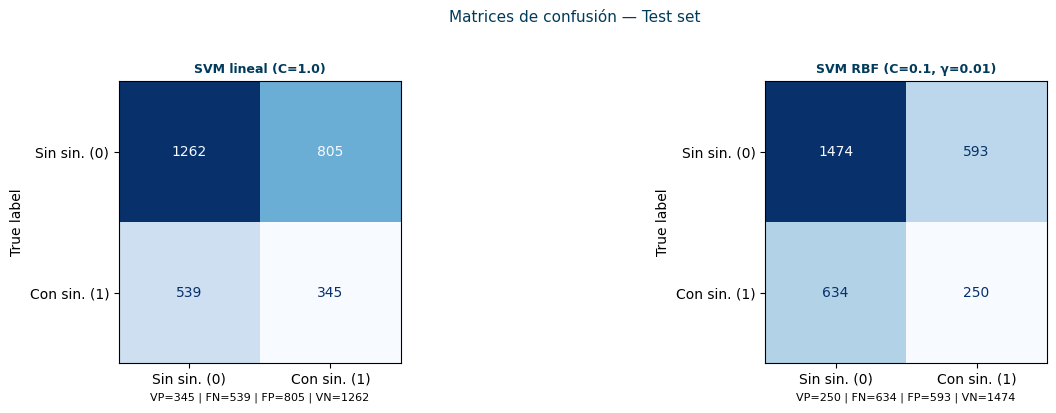

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (nombre, y_pred, _) in zip(axes, modelos):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Sin sin. (0)", "Con sin. (1)"],
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre, fontsize=9, color=NAVY, fontweight="bold")
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f"VP={tp} | FN={fn} | FP={fp} | VN={tn}", fontsize=8)

plt.suptitle("Matrices de confusión — Test set", fontsize=11, color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

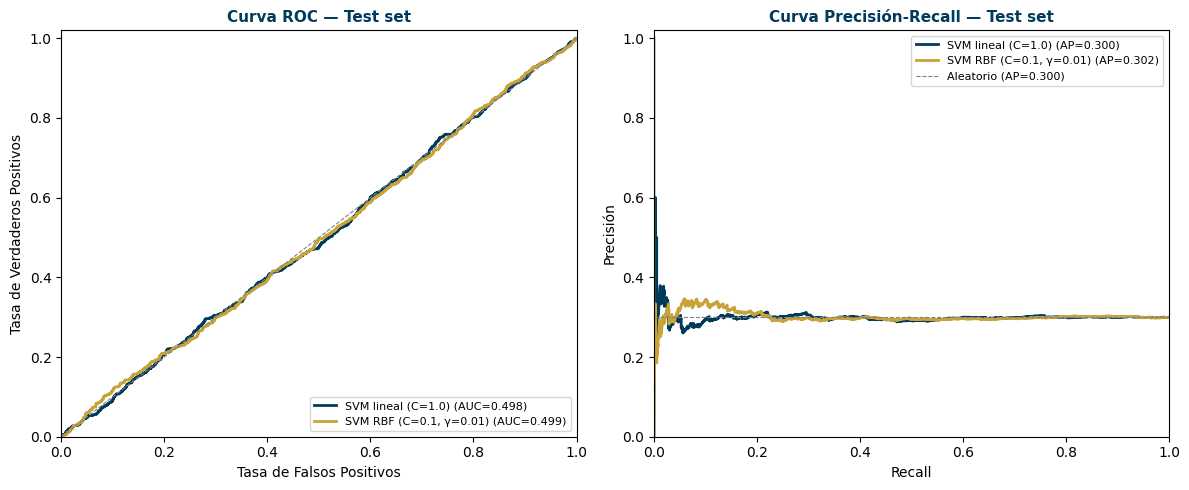

In [87]:
colores_modelos = [NAVY, GOLD]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for (nombre, y_pred, y_score), color in zip(modelos, colores_modelos):
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    ax1.plot(fpr, tpr, color=color, linewidth=2.0,
             label=f"{nombre} (AUC={auc:.3f})")

    # Curva PR
    prec, rec, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    ax2.plot(rec, prec, color=color, linewidth=2.0,
             label=f"{nombre} (AP={ap:.3f})")

ax1.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
ax1.set_xlabel("Tasa de Falsos Positivos")
ax1.set_ylabel("Tasa de Verdaderos Positivos")
ax1.set_title("Curva ROC — Test set", fontsize=11, color=NAVY, fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])

base_ap = y_test.mean()  # AP del clasificador aleatorio
ax2.axhline(base_ap, color="gray", linewidth=0.8, linestyle="--",
            label=f"Aleatorio (AP={base_ap:.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precisión")
ax2.set_title("Curva Precisión-Recall — Test set", fontsize=11, color=NAVY, fontweight="bold")
ax2.legend(fontsize=8, loc="upper right")
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

Pruebas Random Forest y XGBoost

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline_rf = Pipeline([
    ("preprocessor", make_svm_preprocessor()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)
y_score_rf = pipeline_rf.predict_proba(X_test)[:,1]

In [89]:
from xgboost import XGBClassifier

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

pipeline_xgb = Pipeline([
    ("preprocessor", make_svm_preprocessor()),
    ("xgb", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos,
        random_state=SEED
    ))
])

pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)
y_score_xgb = pipeline_xgb.predict_proba(X_test)[:,1]

In [90]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score
)

for nombre, pred, score in [
    ("Random Forest", y_pred_rf, y_score_rf),
    ("XGBoost", y_pred_xgb, y_score_xgb)
]:

    print(f"\n{nombre}")
    print(f"ROC-AUC: {roc_auc_score(y_test, score):.4f}")
    print(f"Average Precision: {average_precision_score(y_test, score):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
    print(f"F1: {f1_score(y_test, pred):.4f}")


Random Forest
ROC-AUC: 0.4993
Average Precision: 0.3032
Balanced Accuracy: 0.5010
F1: 0.1156

XGBoost
ROC-AUC: 0.5152
Average Precision: 0.3201
Balanced Accuracy: 0.5157
F1: 0.3531


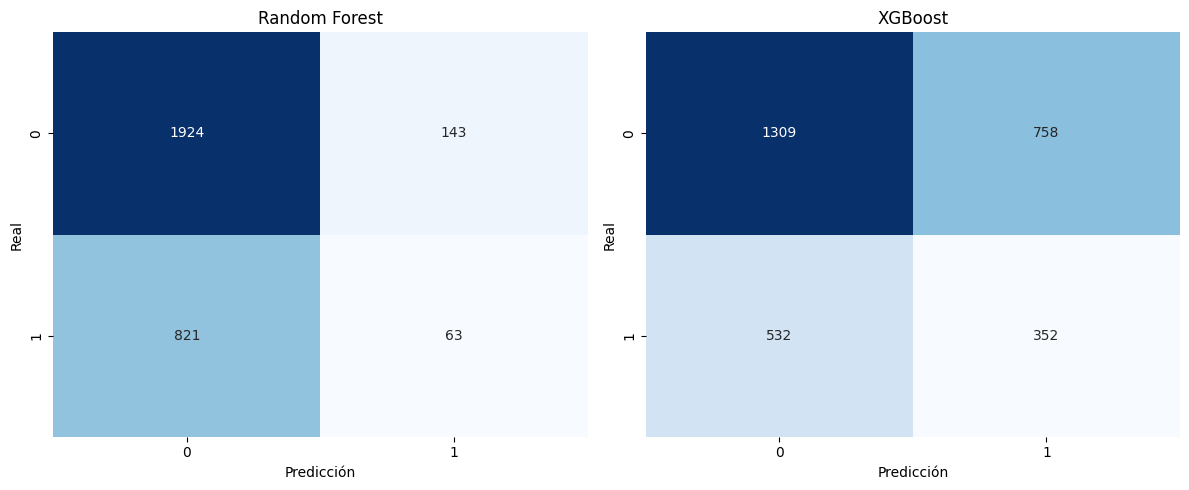

In [91]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1,2, figsize=(12,5))

for i, (nombre, pred) in enumerate([
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax[i]
    )

    ax[i].set_title(nombre)
    ax[i].set_xlabel("Predicción")
    ax[i].set_ylabel("Real")

plt.tight_layout()
plt.show()

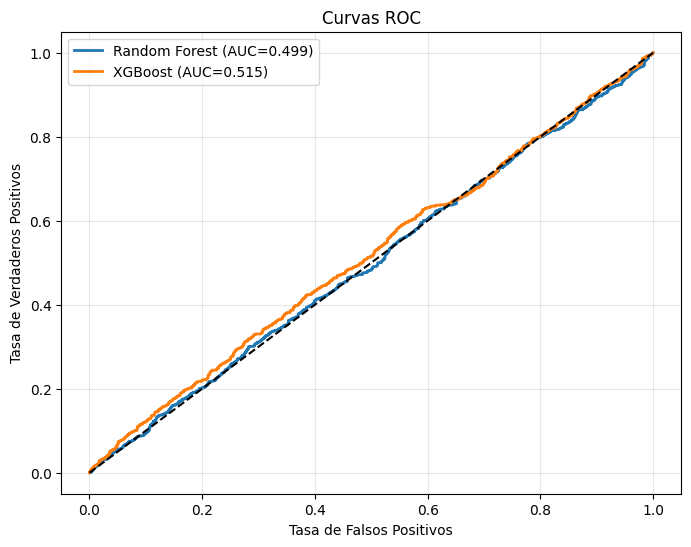

In [92]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_score_xgb)

auc_rf = roc_auc_score(y_test, y_score_rf)
auc_xgb = roc_auc_score(y_test, y_score_xgb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    lw=2,
    label=f"Random Forest (AUC={auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    lw=2,
    label=f"XGBoost (AUC={auc_xgb:.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC")
plt.legend()

plt.grid(alpha=.3)

plt.show()

Variables para aprendizaje no supervisado

In [103]:
# --- 1. CONFIGURACIÓN Y DEFINICIONES ---
# (Tus listas originales integradas)
cols_features = [
    'edad', 'sexo', 'estado_civil', 'ocupacion', 'plan',
    'fecha_emision', 'fecha_inicio_vigencia', 'fecha_fin_vigencia',
    'num_renovaciones', 'status_poliza', 'motivo_baja', 'canal_venta',
    'marca_vehiculo', 'modelo_vehiculo', 'tipo_vehiculo', 'suma_asegurada',
    'deducible', 'prima_total', 'forma_pago', 'estado', 'codigo_postal',
    'region', 'monto_reclamado', 'tiene_abierto', 'prima_mensual',
    'nivel_riesgo', 'anio_emision', 'mes_emision', 'trimestre',
    'segmento_prima_fijo', 'cuartil_prima', 'anio_poliza',
    'antiguedad_vehiculo', 'g_edad'
]

num_features = ['edad', 'num_renovaciones', 'suma_asegurada','antiguedad_vehiculo']

cat_features = ['plan','canal_venta', 'tipo_vehiculo', 'estado', 'nivel_riesgo']